# Part 2 — Network Analysis

Reference: SNA Final Project guidelines, Part 2.

All analyses in this notebook are run on the **simple, undirected, unweighted** version of the collected Bluesky reply network, and compared against two reference models of the same size:

- **ER** — Erdős–Rényi $G(n, p)$ with $p$ chosen so that the expected number of edges matches the observed graph.
- **BA** — Barabási–Albert preferential attachment with $m$ chosen so that the resulting number of edges matches the observed graph.

Sections:
1. Setup and graph simplification
2. Reference models (ER, BA)
3. Basic descriptive statistics
4. Degree distribution and power-law fit
5. Connected components
6. Path analysis (diameter, average shortest path)
7. Clustering coefficient and density
8. Centrality measures (degree, closeness, betweenness, eigenvector, PageRank)

## 1. Setup and graph simplification

In [1]:
import os
import math
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

INPUT_FILE = 'private/dataset_roberta_final.gexf'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)

In [2]:
# Load directed graph as collected
G_dir = nx.read_gexf(INPUT_FILE)
print(f'Original (directed): N={G_dir.number_of_nodes()}, M={G_dir.number_of_edges()}')

# Simplification: undirected, unweighted, no self-loops, no parallel edges
G = nx.Graph()
G.add_nodes_from(G_dir.nodes())
for u, v in G_dir.edges():
    if u != v:
        G.add_edge(u, v)

print(f'Simplified (undirected, unweighted, simple): N={G.number_of_nodes()}, M={G.number_of_edges()}')
print(f'Self-loops removed: {sum(1 for u, v in G_dir.edges() if u == v)}')
print(f'Reciprocated directed pairs collapsed: {G_dir.number_of_edges() - G.number_of_edges() - sum(1 for u, v in G_dir.edges() if u == v)}')

Original (directed): N=10855, M=14011
Simplified (undirected, unweighted, simple): N=10855, M=13462
Self-loops removed: 0
Reciprocated directed pairs collapsed: 549


## 2. Reference models (ER, BA)

Both reference graphs have the same number of nodes $N$ as $G$. Parameters are chosen to make the expected number of edges match $M$:

- **ER**: $p = \dfrac{2M}{N(N-1)}$
- **BA**: $m \approx \left\lfloor \dfrac{M}{N} \right\rfloor$ (using $m$ initial attachments per new node)

In [3]:
N = G.number_of_nodes()
M = G.number_of_edges()

p_er = 2 * M / (N * (N - 1))
m_ba = max(1, round(M / N))

print(f'Building ER  with N={N}, p={p_er:.6e}')
G_er = nx.fast_gnp_random_graph(N, p_er, seed=RNG_SEED)
print(f'  → M_ER = {G_er.number_of_edges()}')

print(f'Building BA  with N={N}, m={m_ba}')
G_ba = nx.barabasi_albert_graph(N, m_ba, seed=RNG_SEED)
print(f'  → M_BA = {G_ba.number_of_edges()}')

Building ER  with N=10855, p=2.285177e-04
  → M_ER = 13439
Building BA  with N=10855, m=1
  → M_BA = 10854


## 3. Basic descriptive statistics

In [4]:
def basic_stats(g, name):
    n = g.number_of_nodes()
    m = g.number_of_edges()
    degrees = [d for _, d in g.degree()]
    return {
        'graph': name,
        'N': n,
        'M': m,
        'density': nx.density(g),
        'avg_degree': np.mean(degrees),
        'max_degree': np.max(degrees),
        'min_degree': np.min(degrees),
        'std_degree': np.std(degrees),
    }

stats_df = pd.DataFrame([basic_stats(G, 'Bluesky'), basic_stats(G_er, 'ER'), basic_stats(G_ba, 'BA')])
stats_df.set_index('graph')

,N,M,density,avg_degree,max_degree,min_degree,std_degree
graph,,,,,,,
Bluesky,10855,13462,0.000229,2.480332,916,1,14.711115
ER,10855,13439,0.000228,2.476094,11,0,1.560969
BA,10855,10854,0.000184,1.999816,307,1,4.260257


## 4. Degree distribution and power-law fit

We expect:
- **ER** → Poisson-like degree distribution with thin tail.
- **BA** → power-law $P(k) \propto k^{-3}$.
- **Bluesky reply network** → typically scale-free / heavy-tailed, since few popular accounts attract most replies.

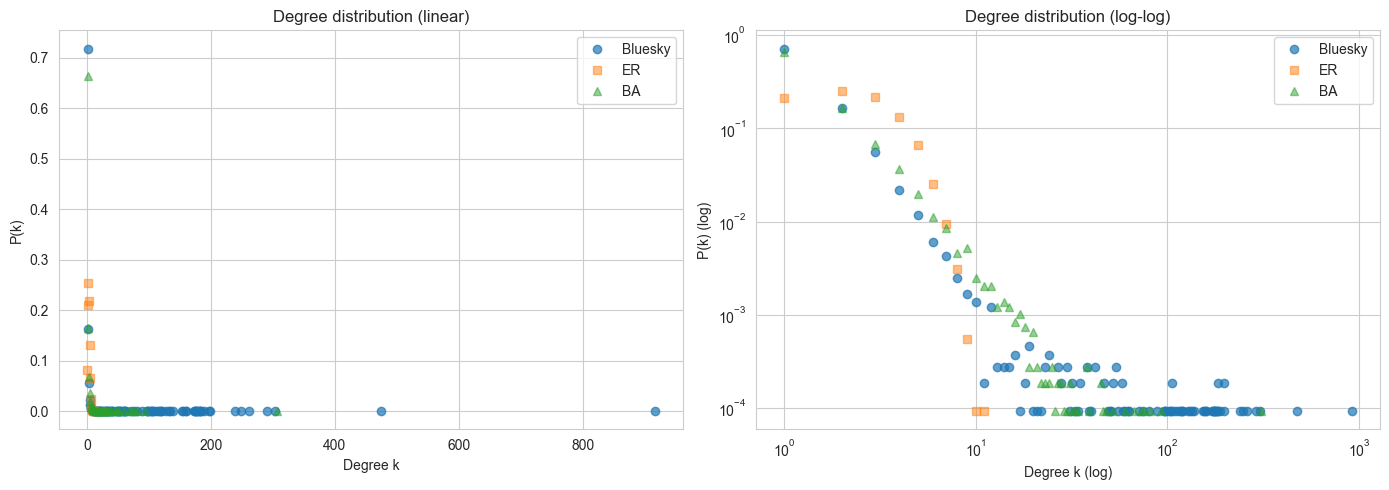

In [5]:
def degree_dist(g):
    degs = [d for _, d in g.degree()]
    counts = Counter(degs)
    ks = np.array(sorted(counts.keys()))
    pks = np.array([counts[k] for k in ks], dtype=float)
    pks = pks / pks.sum()
    return ks, pks, degs

ks_g,  pks_g,  degs_g  = degree_dist(G)
ks_er, pks_er, degs_er = degree_dist(G_er)
ks_ba, pks_ba, degs_ba = degree_dist(G_ba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks_g,  pks_g,  'o', label='Bluesky',     alpha=0.7)
axes[0].plot(ks_er, pks_er, 's', label='ER',          alpha=0.5)
axes[0].plot(ks_ba, pks_ba, '^', label='BA',          alpha=0.5)
axes[0].set_xlabel('Degree k'); axes[0].set_ylabel('P(k)')
axes[0].set_title('Degree distribution (linear)')
axes[0].legend()

axes[1].loglog(ks_g[ks_g > 0],  pks_g[ks_g > 0],  'o', label='Bluesky', alpha=0.7)
axes[1].loglog(ks_er[ks_er > 0], pks_er[ks_er > 0], 's', label='ER',     alpha=0.5)
axes[1].loglog(ks_ba[ks_ba > 0], pks_ba[ks_ba > 0], '^', label='BA',     alpha=0.5)
axes[1].set_xlabel('Degree k (log)'); axes[1].set_ylabel('P(k) (log)')
axes[1].set_title('Degree distribution (log-log)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Complementary cumulative distribution function (CCDF) — robust visualisation for heavy-tailed data
def ccdf(values):
    sorted_vals = np.sort(values)
    cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
    return sorted_vals, 1.0 - cdf

fig, ax = plt.subplots(figsize=(8, 6))
for degs, label, marker in [(degs_g, 'Bluesky', 'o'), (degs_er, 'ER', 's'), (degs_ba, 'BA', '^')]:
    x, y = ccdf(degs)
    mask = (x > 0) & (y > 0)
    ax.loglog(x[mask], y[mask], marker, label=label, markersize=3, alpha=0.6)
ax.set_xlabel('Degree k')
ax.set_ylabel('P(K >= k)')
ax.set_title('CCDF — degree distribution')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/degree_ccdf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Power-law fit (try the powerlaw library; fall back to a simple log-log linear regression)
try:
    import powerlaw  # noqa: F401
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False
    print("`powerlaw` not installed — falling back to log-log OLS. Install with: pip install powerlaw")

if HAVE_POWERLAW:
    import powerlaw
    fit = powerlaw.Fit(degs_g, discrete=True, verbose=False)
    print(f'Estimated power-law exponent alpha = {fit.alpha:.3f}')
    print(f'k_min (xmin)                       = {fit.xmin}')
    R, p = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)
    print(f'Power-law vs Lognormal: R={R:.3f}, p={p:.3f} (R>0 favors power-law)')
    R, p = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)
    print(f'Power-law vs Exponential: R={R:.3f}, p={p:.3f} (R>0 favors power-law)')
else:
    # Fallback: linear regression on log-log of empirical P(k)
    mask = (ks_g >= 5) & (pks_g > 0)
    logk = np.log(ks_g[mask]); logp = np.log(pks_g[mask])
    slope, intercept = np.polyfit(logk, logp, 1)
    print(f'OLS log-log fit (k>=5): slope={slope:.3f}  →  alpha ≈ {-slope:.3f}')

## 5. Connected components

In [ ]:
def cc_summary(g, name):
    cc_sizes = sorted([len(c) for c in nx.connected_components(g)], reverse=True)
    return {
        'graph': name,
        'num_components': len(cc_sizes),
        'GCC_size': cc_sizes[0],
        'GCC_fraction': cc_sizes[0] / g.number_of_nodes(),
        '2nd_cc_size': cc_sizes[1] if len(cc_sizes) > 1 else 0,
        'isolates': sum(1 for s in cc_sizes if s == 1),
    }

cc_df = pd.DataFrame([cc_summary(G, 'Bluesky'), cc_summary(G_er, 'ER'), cc_summary(G_ba, 'BA')])
cc_df.set_index('graph')

In [ ]:
# Distribution of CC sizes (Bluesky)
cc_sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(len(cc_sizes[:15])), cc_sizes[:15], color='steelblue', edgecolor='black')
axes[0].set_yscale('log')
axes[0].set_title('Top-15 CC sizes (Bluesky, log scale)')
axes[0].set_xlabel('Component rank'); axes[0].set_ylabel('Size')

size_counts = Counter(cc_sizes)
axes[1].loglog(sorted(size_counts.keys()), [size_counts[k] for k in sorted(size_counts.keys())], 'o', alpha=0.7)
axes[1].set_title('CC size distribution (Bluesky)')
axes[1].set_xlabel('CC size'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/connected_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Restrict path/clustering analyses to the giant connected component (GCC) for each graph
def gcc(g):
    return g.subgraph(max(nx.connected_components(g), key=len)).copy()

G_gcc    = gcc(G)
G_er_gcc = gcc(G_er)
G_ba_gcc = gcc(G_ba)  # BA is connected by construction

for name, g in [('Bluesky', G_gcc), ('ER', G_er_gcc), ('BA', G_ba_gcc)]:
    print(f'{name:8s} GCC: N={g.number_of_nodes()}, M={g.number_of_edges()}')

## 6. Path analysis

Diameter and average shortest path length on the GCC. Because BFS from every node is $O(N \cdot (N+M))$, we **sample** source nodes when the graph is large.

In [ ]:
def path_stats_sampled(g, n_samples=300, seed=RNG_SEED):
    """Estimate avg shortest path length and (lower bound on) diameter by sampling source nodes."""
    rng = random.Random(seed)
    nodes = list(g.nodes())
    sampled = rng.sample(nodes, min(n_samples, len(nodes)))
    all_lengths = []
    diameter_lb = 0
    for src in tqdm(sampled, desc='BFS sampling'):
        lengths = nx.single_source_shortest_path_length(g, src)
        ls = list(lengths.values())
        all_lengths.extend(ls)
        diameter_lb = max(diameter_lb, max(ls))
    return float(np.mean(all_lengths)), diameter_lb

path_results = []
for name, g in [('Bluesky', G_gcc), ('ER', G_er_gcc), ('BA', G_ba_gcc)]:
    avg_sp, diam_lb = path_stats_sampled(g, n_samples=300)
    path_results.append({'graph': name, 'avg_shortest_path': avg_sp, 'diameter_lb': diam_lb})
    print(f'{name:8s} → avg shortest path ≈ {avg_sp:.3f}, diameter (lower bound) = {diam_lb}')

pd.DataFrame(path_results).set_index('graph')

## 7. Clustering coefficient and density

In [ ]:
def clustering_summary(g, name):
    avg_clust  = nx.average_clustering(g)
    transitivity = nx.transitivity(g)
    return {'graph': name, 'avg_clustering': avg_clust, 'transitivity': transitivity, 'density': nx.density(g)}

clust_df = pd.DataFrame([clustering_summary(G, 'Bluesky'),
                          clustering_summary(G_er, 'ER'),
                          clustering_summary(G_ba, 'BA')])
clust_df.set_index('graph')

In [ ]:
# Distribution of local clustering coefficient (Bluesky GCC vs ER GCC vs BA GCC)
fig, ax = plt.subplots(figsize=(9, 5))
for name, g, color in [('Bluesky', G_gcc, 'steelblue'), ('ER', G_er_gcc, 'orange'), ('BA', G_ba_gcc, 'green')]:
    cc_local = list(nx.clustering(g).values())
    sns.kdeplot(cc_local, label=name, color=color, ax=ax, clip=(0, 1))
ax.set_xlabel('Local clustering coefficient')
ax.set_ylabel('Density')
ax.set_title('Local clustering — distribution comparison (GCC)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/clustering_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Centrality measures

Computed on the GCC of the Bluesky graph. Five centralities are reported:

1. **Degree centrality** — number of neighbours, normalised by $N-1$.
2. **Closeness centrality** — inverse mean shortest-path distance to every other node.
3. **Betweenness centrality** — fraction of shortest paths going through a node (estimated by sampling sources).
4. **Eigenvector centrality** — recursive: a node is important if its neighbours are important.
5. **PageRank** — random-walk-based, with damping factor $0.85$.

We then look at the **top-15 nodes** for each measure and at the **rank correlation** (Spearman) between centralities.

In [ ]:
print('Computing degree centrality...')
deg_c   = nx.degree_centrality(G_gcc)

print('Computing closeness centrality (this can take a few minutes)...')
# For very large graphs, restrict to a sample of source nodes if needed.
close_c = nx.closeness_centrality(G_gcc)

print('Computing betweenness centrality (sampled k=500)...')
btw_c   = nx.betweenness_centrality(G_gcc, k=min(500, G_gcc.number_of_nodes()), seed=RNG_SEED, normalized=True)

print('Computing eigenvector centrality (power iteration)...')
try:
    eig_c = nx.eigenvector_centrality(G_gcc, max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eig_c = nx.eigenvector_centrality_numpy(G_gcc)

print('Computing PageRank...')
pr_c    = nx.pagerank(G_gcc, alpha=0.85)

centrality_df = pd.DataFrame({
    'degree':      pd.Series(deg_c),
    'closeness':   pd.Series(close_c),
    'betweenness': pd.Series(btw_c),
    'eigenvector': pd.Series(eig_c),
    'pagerank':    pd.Series(pr_c),
})
print(f'Computed centralities on {len(centrality_df)} nodes')
centrality_df.describe()

In [ ]:
# Top-15 nodes for each centrality
TOP_K = 15
top_nodes = {}
for col in centrality_df.columns:
    top_nodes[col] = centrality_df[col].sort_values(ascending=False).head(TOP_K)

for col, series in top_nodes.items():
    print(f'\n--- Top {TOP_K} by {col.upper()} ---')
    for rank, (node, val) in enumerate(series.items(), 1):
        print(f'  {rank:>2}. {node:<35s} {val:.5f}')

In [ ]:
# Rank correlation between centralities (Spearman)
corr = centrality_df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Spearman rank correlation between centralities')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/centrality_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Visualise centrality distributions on log scale (heavy-tailed for scale-free networks)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, centrality_df.columns):
    vals = centrality_df[col].values
    vals = vals[vals > 0]
    ax.hist(vals, bins=50, color='steelblue', edgecolor='black')
    ax.set_yscale('log')
    ax.set_title(col)
    ax.set_xlabel('value'); ax.set_ylabel('count (log)')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/centrality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Persist all centralities back onto the original simplified graph for use in Part 3 / Part 4
for col in centrality_df.columns:
    nx.set_node_attributes(G, centrality_df[col].to_dict(), f'centrality_{col}')

OUTPUT_FILE = 'private/dataset_part2_with_centralities.gexf'
nx.write_gexf(G, OUTPUT_FILE)
print(f'Saved: {OUTPUT_FILE}')

# Also save the centrality table as CSV for the report
centrality_df.to_csv('centrality_table.csv')
print('Saved: centrality_table.csv')

## Summary of findings (to be filled in the report)

Use the `stats_df`, `cc_df`, `path_results`, `clust_df`, `centrality_df` objects above to fill the comparative table in the report. Expected qualitative observations:

- The Bluesky reply network has a **heavy-tailed degree distribution** (similar to BA, very different from ER).
- A **small fraction of "hub" accounts** dominates the conversation: highest degree, betweenness, and PageRank concentrate on the same few nodes.
- The graph is **sparse** but exhibits **small-world** properties on the GCC: short average path despite low density.
- **Clustering** is higher than ER (random) but typically lower than what triadic closure-driven processes would produce, consistent with reply-graph topology.
- Degree, eigenvector and PageRank are usually highly correlated (Spearman > 0.8); betweenness highlights different *bridge* nodes.